1. Імпорти

In [5]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 500)

2. Завантаження даних

In [6]:
df = pd.read_json(
    "../data/raw/tesoro_comment.json",
    lines=True
)

print(df.shape)

(4981, 9)


3. Огляд

In [7]:
df.head()

,id,comment_id,comment,code,classification,isFinished,code_context_2,code_context_10,code_context_20
0,24576,0,"// If a manifest doesn't have a version, the other attributes won't get written out. Lame.","private void addEntriesToMainManifest(Manifest manifest) {\n Attributes attrs = manifest.getMainAttributes();\n // If a manifest doesn't have a version, the other attributes won't get written out. Lame.\n attrs.put(Attributes.Name.MANIFEST_VERSION, new Date().toString());\n for (Map.Entry<Attributes.Name, String> entry : this.manifestEntries.entrySet()) {\n attrs.put(entry.getKey(), entry.getValue());\n }\n }",DEFECT,True,"private void addEntriesToMainManifest(Manifest manifest) {\nAttributes attrs = manifest.getMainAttributes();\n// If a manifest doesn't have a version, the other attributes won't get written out. Lame.\nattrs.put(Attributes.Name.MANIFEST_VERSION, new Date().toString());\nfor (Map.Entry<Attributes.Name, String> entry : this.manifestEntries.entrySet()) {","private void addEntriesToMainManifest(Manifest manifest) {\nAttributes attrs = manifest.getMainAttributes();\n// If a manifest doesn't have a version, the other attributes won't get written out. Lame.\nattrs.put(Attributes.Name.MANIFEST_VERSION, new Date().toString());\nfor (Map.Entry<Attributes.Name, String> entry : this.manifestEntries.entrySet()) {\nattrs.put(entry.getKey(), entry.getValue());\n}\n}","private void addEntriesToMainManifest(Manifest manifest) {\nAttributes attrs = manifest.getMainAttributes();\n// If a manifest doesn't have a version, the other attributes won't get written out. Lame.\nattrs.put(Attributes.Name.MANIFEST_VERSION, new Date().toString());\nfor (Map.Entry<Attributes.Name, String> entry : this.manifestEntries.entrySet()) {\nattrs.put(entry.getKey(), entry.getValue());\n}\n}"
1,22,0,// FIXME: this is almost certainly boned. a Reg could appear in the\n// address expressions.,public boolean usesRegs() {\n // FIXME: this is almost certainly boned. a Reg could appear in the\n // address expressions.\n for (int i=0;i<rhs().length;++i) {\n if (usesDirectly(i) && rhs()[i] instanceof Reg) {\n return true;\n }\n }\n if (opcode.form().implicitUses(head().code()).length!=0) {\n return true;\n }\n return false;\n },DEFECT,True,public boolean usesRegs() {\n// FIXME: this is almost certainly boned. a Reg could appear in the\n// address expressions.\nfor (int i=0;i<rhs().length;++i) {\nif (usesDirectly(i) && rhs()[i] instanceof Reg) {,public boolean usesRegs() {\n// FIXME: this is almost certainly boned. a Reg could appear in the\n// address expressions.\nfor (int i=0;i<rhs().length;++i) {\nif (usesDirectly(i) && rhs()[i] instanceof Reg) {\nreturn true;\n}\n}\nif (opcode.form().implicitUses(head().code()).length!=0) {\nreturn true;\n}\nreturn false;\n},public boolean usesRegs() {\n// FIXME: this is almost certainly boned. a Reg could appear in the\n// address expressions.\nfor (int i=0;i<rhs().length;++i) {\nif (usesDirectly(i) && rhs()[i] instanceof Reg) {\nreturn true;\n}\n}\nif (opcode.form().implicitUses(head().code()).length!=0) {\nreturn true;\n}\nreturn false;\n}
2,28,0,//TODO: For each model create separate implementation.,"@Override\n public void process(JCas jCas) throws AnalysisEngineProcessException {\n long startTime = System.currentTimeMillis();\n FeatureExtractor fe = new NYTEntitySalienceFeatureExtractor();\n List<EntityInstance> entityInstances;\n try {\n entityInstances = fe.getEntityInstances(jCas, TrainingSettings.FeatureExtractor.ENTITY_SALIENCE);\n final int featureVectorSize = FeatureSetFactory.createFeatureSet(TrainingSettings.FeatureExtractor...",IMPLEMENTATION,True,"entityInstances = fe.getEntityInstances(jCas, TrainingSettings.FeatureExtractor.ENTITY_SALIENCE);\nfinal int featureVectorSize = FeatureSetFactory.createFeatureSet(TrainingSettings.FeatureExtractor.ENTITY_SALIENCE).getFeatureVectorSize();\n//TODO: For each model create separate implementation.\nRandomForestClassificationModel rfm = (RandomForestClassificatio

4. Колонки

In [8]:
df.columns.tolist()

['id',
 'comment_id',
 'comment',
 'code',
 'classification',
 'isFinished',
 'code_context_2',
 'code_context_10',
 'code_context_20']

5. Типи

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               4981 non-null   int64
 1   comment_id       4981 non-null   int64
 2   comment          4981 non-null   str  
 3   code             4981 non-null   str  
 4   classification   4981 non-null   str  
 5   isFinished       4981 non-null   bool 
 6   code_context_2   4981 non-null   str  
 7   code_context_10  4981 non-null   str  
 8   code_context_20  4981 non-null   str  
dtypes: bool(1), int64(2), str(6)
memory usage: 84.4 MB


6. Пропущені значення

In [10]:
df.isnull().sum()

id                 0
comment_id         0
comment            0
code               0
classification     0
isFinished         0
code_context_2     0
code_context_10    0
code_context_20    0
dtype: int64

7. Дублікати

In [11]:
df.duplicated().sum()

np.int64(0)

8. Баланс класів (ДУЖЕ ВАЖЛИВО)

In [14]:
df["classification"].value_counts()

classification
NONSATD           3432
DESIGN             697
IMPLEMENTATION     474
DEFECT             220
DOCUMENTATION       80
TEST                78
Name: count, dtype: int64

Візуалізація

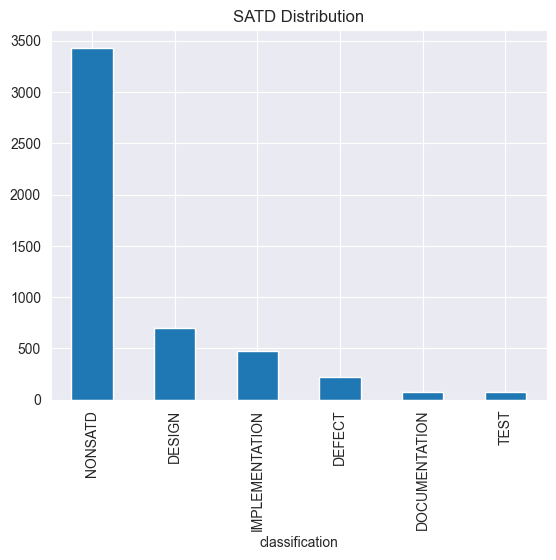

In [15]:
df["classification"].value_counts().plot(kind="bar")
plt.title("SATD Distribution")
plt.show()

9. Аналіз тексту (ключове!)

In [16]:
text_cols = ["comment", "code"]

for col in text_cols:
    if col in df.columns:
        df[f"{col}_len"] = df[col].astype(str).str.len()

Статистика

In [17]:
df[[c for c in df.columns if c.endswith("_len")]].describe().T

,count,mean,std,min,25%,50%,75%,max
comment_len,4981.0,94.442481,145.793261,2.0,30.0,57.0,97.0,2549.0
code_len,4981.0,15070.735997,27847.392629,31.0,1138.0,3094.0,11401.0,107200.0


10. Гістограми

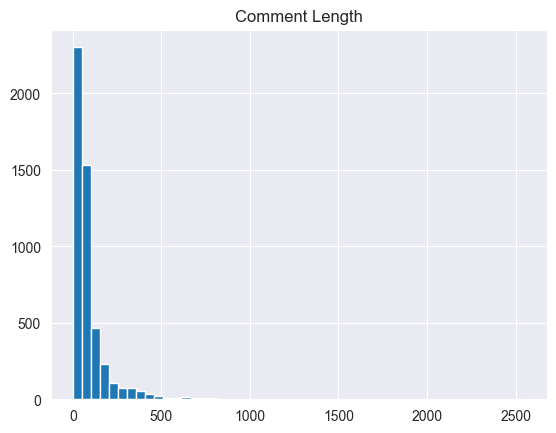

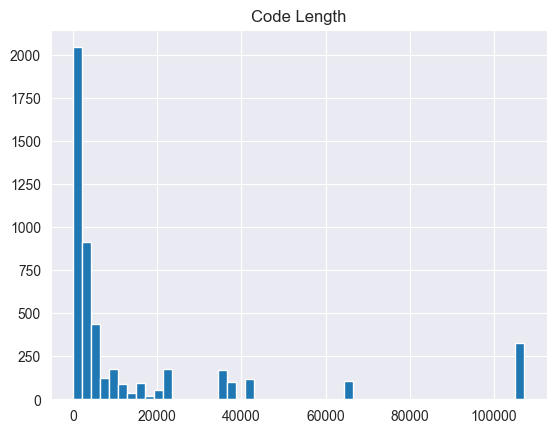

In [18]:
df["comment_len"].hist(bins=50)
plt.title("Comment Length")
plt.show()

df["code_len"].hist(bins=50)
plt.title("Code Length")
plt.show()

11. Boxplots

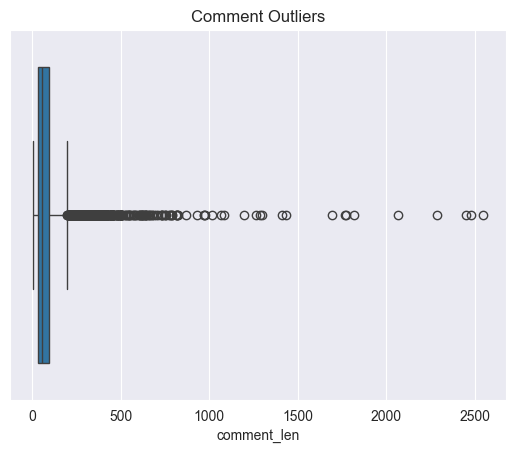

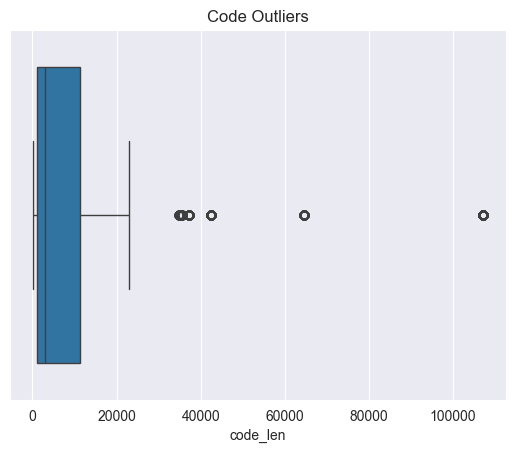

In [19]:
sns.boxplot(x=df["comment_len"])
plt.title("Comment Outliers")
plt.show()

sns.boxplot(x=df["code_len"])
plt.title("Code Outliers")
plt.show()

12. Порівняння SATD vs non-SATD

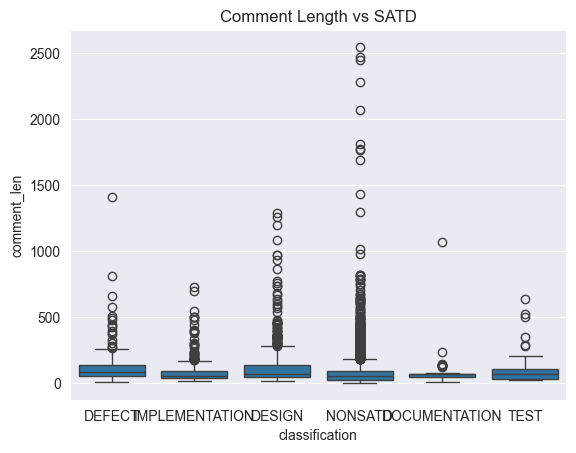

In [20]:
sns.boxplot(x="classification", y="comment_len", data=df)
plt.title("Comment Length vs SATD")
plt.show()

13. Найчастіші слова (коментарі)

In [21]:
from collections import Counter

all_words = " ".join(df["comment"].dropna()).lower().split()

Counter(all_words).most_common(20)

[('//', 4365),
 ('the', 3520),
 ('*', 2462),
 ('to', 1548),
 ('a', 1060),
 ('is', 934),
 ('this', 861),
 ('of', 825),
 ('*/', 784),
 ('for', 741),
 ('if', 663),
 ('we', 628),
 ('in', 613),
 ('and', 545),
 ('todo:', 493),
 ('/**', 482),
 ('be', 476),
 ('@param', 421),
 ('that', 397),
 ('not', 380)]

14. Ключові слова технічного боргу

In [22]:
keywords = ["todo", "fixme", "hack", "bug", "temporary"]

for word in keywords:
    count = df["comment"].str.contains(word, case=False, na=False).sum()
    print(word, ":", count)


todo : 1147
fixme : 105
hack : 28
bug : 73
temporary : 2


15. Кореляція

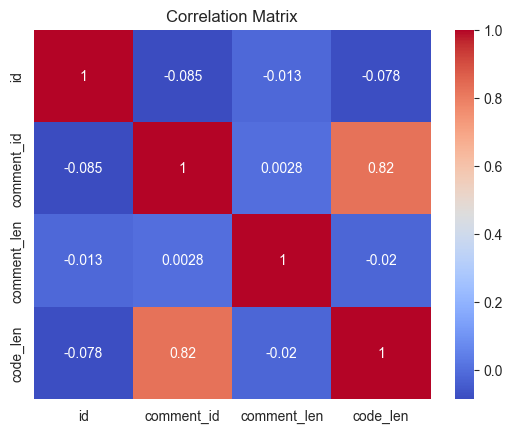

In [23]:
numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

 16. Приклади SATD

In [26]:
df[df["classification"] != "NONSATD"]["comment"].sample(5)

177                                             // TODO SlaveComputer.doSlaveAgentJnlp; there should be an annotation to request unprotected access
3628                                                                         // TODO: Update this logic to also handle the user logged in by email.
428                                                                                                // TODO: customize your mock logic for s3 client
161                                                                                                          /**\n     * TODO implement me\n     */
4277    // create a rev with an attachment, then update it keeping attachment\n// TODO we need to somehow check the attachment wasn't re-downloaded
Name: comment, dtype: str

17. Приклади НЕ SATD

In [27]:
df[df["classification"] == "NONSATD"]["comment"].sample(5)

3250                                                                     //|| src[pos] == close)
3805                                                       //Configuration options for HasLocale
1154                     /**\n     * Test of getVotesForInstance method, of class FeS2.\n     */
1362                                                                                  // control
1018    // in-place update failed, so fall through and re-try the same with a full atomic update
Name: comment, dtype: str